In [47]:
import warnings
warnings.filterwarnings('ignore')

# Linear Regression

In linear function, the output variable $y$ is approximated as a linear function of the input variables $x$. The hypothesis $h_{\theta}(x)$ can thus be defined as:

$$
h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_{d}x_{d} \\
h_{\theta}(x) = \sum_{i=0}^{d}\theta_i x_i
$$

In vector form:
$$
h_{\theta}(x) = \theta^{T}x
$$

where,
$$
\begin{align*}
&\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_{d} \end{bmatrix}_{d\times 1} \text{are the parameters}\\
&x = \begin{bmatrix} x_0 \\ x_1 \\ \vdots \\ x_{d} \end{bmatrix}_{d\times 1} \text{are the features}\\
&\theta_0 \text{ is the intercept term} \\
&x_0=1 \text{ is the dummy parameter introduced for mathematical convenience}
\end{align*}
$$

## Learning the parameters $(\Theta)$

One way to learn/estimate the parameters is to make sure $h_\theta(x)$ is as close to $y$ as possible for the rows in the training set. This can be described mathematically by what is known as a *cost function* $J(\theta)$:

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)^2 
$$

This method of estimating $\theta$ by minimizing the sum of the squared errors/residuals is called the **Ordinary Least Squares Regression Model** and the associated cost function is called the *Least Squares Cost Function*.

### Estimating $\Theta$: Normal Equations

Let us define:
$$
\mathrm{X} = \begin{bmatrix}
    (x^{(1)})^{T} \\
    (x^{(2)})^{T} \\
    \vdots \\
    (x^{(n)})^{T} \\
\end{bmatrix}_{n\times (d+1)}\quad

\mathrm{Y} = \begin{bmatrix}
    y^{(1)} \\
    y^{(2)} \\
    \vdots \\
    y^{(n)} \\
\end{bmatrix}_{n\times 1} \quad

\Theta = \begin{bmatrix}
    \theta_{0} \\
    \theta_{1} \\
    \vdots \\
    \theta_{d} \\
\end{bmatrix}_{(d+1)\times 1}
$$

Then,
$$
J(\Theta) = \frac{1}{2}\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)^2 = \frac{1}{2}(\mathrm{X}\Theta - \mathrm{Y})^T\cdot(\mathrm{X}\Theta - \mathrm{Y})
$$

To minimize $J(\Theta)$, we set the gradient to 0:

$$
\begin{align*}

\nabla_{\Theta} J(\Theta) &= 0 \\
\nabla_{\Theta} \Big((\mathrm{X}\Theta - \mathrm{Y})^T\cdot(\mathrm{X}\Theta - \mathrm{Y})\Big) &= 0 \\
(\mathrm{X}\Theta - \mathrm{Y})^T \cdot \nabla_{\Theta} (\mathrm{X}\Theta - \mathrm{Y}) + \nabla_{\Theta}(\mathrm{X}\Theta - \mathrm{Y})^{T}\cdot(\mathrm{X}\Theta - \mathrm{Y}) &= 0 \\
(\mathrm{X}\Theta - \mathrm{Y})^T \cdot X + \mathrm{X}^{T}\cdot(\mathrm{X}\Theta - \mathrm{Y}) &= 0 \\
(\mathrm{X}\Theta)^T \cdot \mathrm{X} - \mathrm{Y}^{T}\mathrm{X} + \mathrm{X}^{T}\cdot(\mathrm{X}\Theta) - \mathrm{X}^{T}\mathrm{Y} &= 0 \\
\big(\mathrm{X}^{T}\cdot(\mathrm{X}\Theta)\big)^{T} - \big(\mathrm{X}^{T}\mathrm{Y}\big)^{T} + \mathrm{X}^{T}\cdot(\mathrm{X}\Theta) - \mathrm{X}^{T}\mathrm{Y} &= 0 \\
2\mathrm{X}^{T}\cdot(\mathrm{X}\Theta) - 2\mathrm{X}^{T}\mathrm{Y} &= 0 \\
\mathrm{X}^{T}\cdot(\mathrm{X}\Theta) &= \mathrm{X}^{T}\mathrm{Y} \\
\Theta &= \mathrm{X}^{-1}(\mathrm{X}^{T})^{-1}\mathrm{X}^{T}\mathrm{Y} \\
\Theta &= (\mathrm{X}^{T}\mathrm{X})^{-1}\mathrm{X}^{T}\mathrm{Y} \\

\end{align*}
$$

Therefore, the value of the $\Theta$ that minimizes the cost function $J(\Theta)$ is given by:
$$
\boxed{\Theta = (\mathrm{X}^{T}\mathrm{X})^{-1}\mathrm{X}^{T}\mathrm{Y}} \\
$$

The above set of equations are called the **normal equations**. These equations give us a method to compute the model parameters in one shot. However this comes with a number of downsides:
1. Computing the inverse of a $d\times d$ matrix is $O(d^3)$ time complexity. More the number of features, bigger the time complexity.
2. Storing the inverse itself is expensive: $O(d^2)$ space complexity.
3. $X^{T}X$ may not be an invertible matrix. This can happen if:
    - one or more features are linearly dependent (temperature in fahrenheit and celsius).
    - features are highly correlated, wherein 2 or more features may be related to one other for example (weight and height).
    - the number of features is more than the number of training examples $(d \geq n)$, since we are trying to estimate the solution to a system of linear equations where number of equations is lesser than the number of unknowns.

### Linear Regression Analysis on California Housing Dataset using Normal equations

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


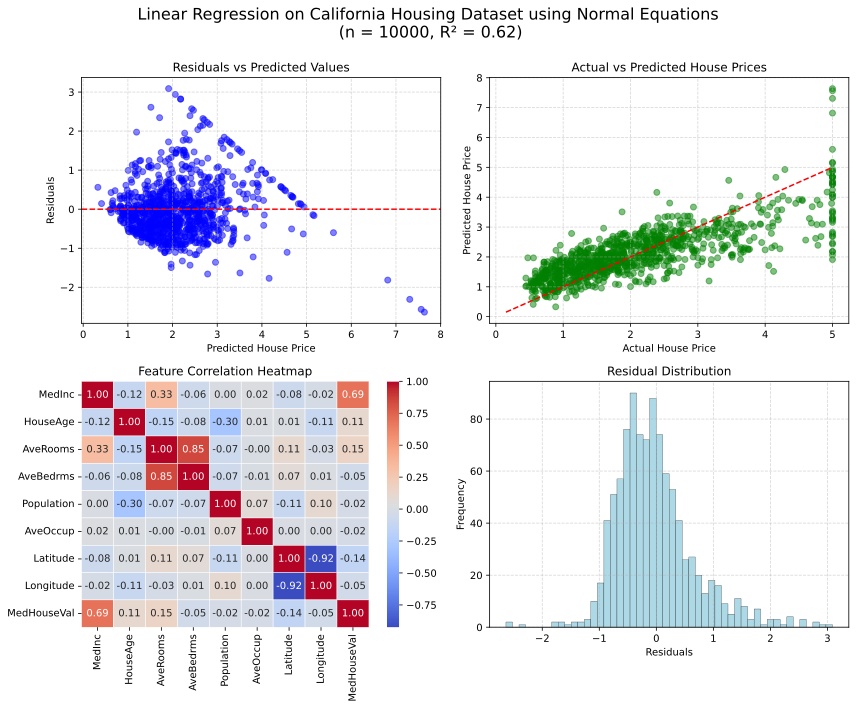

In [48]:
%config InlineBackend.figure_format = 'svg'
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import random

X = fetch_california_housing().data
Y = fetch_california_housing().target

df = pd.DataFrame(X, columns=fetch_california_housing().feature_names)
df["MedHouseVal"] = Y

print(df.head())

# sample X and Y for training
training_sample_size = 10000
indices = random.sample(range(X.shape[0]), training_sample_size)
X_train = X[indices]
Y_train = Y[indices]

# compute the parameters using the normal equation
Theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

# test the model on a set of random samples
test_samples_size = 1000
indices = random.sample(range(X.shape[0]), test_samples_size)
X_test = X[indices]
Y_test = Y[indices]
Y_pred = X_test @ Theta

# errors
residuals = Y_test - Y_pred

# calculate R-squared
ss_total = np.sum((Y_test - np.mean(Y_test)) ** 2)
ss_residual = np.sum((Y_test - Y_pred) ** 2)
r_squared = 1 - (ss_residual / ss_total)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(Y_pred, residuals, alpha=0.5, color='blue')
axes[0, 0].axhline(0, color='red', linestyle='--') # line for zero residuals
axes[0, 0].set_xlabel("Predicted House Price")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Predicted Values")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].scatter(Y_test, Y_pred, alpha=0.5, color='green')
axes[0, 1].plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--') # line for perfect predictions
axes[0, 1].set_xlabel("Actual House Price")
axes[0, 1].set_ylabel("Predicted House Price")
axes[0, 1].set_title("Actual vs Predicted House Prices")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Feature Correlation Heatmap")

axes[1, 1].hist(residuals, bins=50, color='lightblue', linewidth=0.25, edgecolor='black')
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Residual Distribution")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle("Linear Regression on California Housing Dataset using Normal Equations\n (n = {}, R² = {:.2f})".format(training_sample_size, r_squared), fontsize=16)
plt.show()

### Estimating $\Theta$: Gradient Descent - An iterative algorithm